# Import

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from pyspark.sql.functions import when
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Konfigurasi


In [2]:
spark = SparkSession.builder \
    .appName("FraudClassification-UnderSampling") \
    .master("local[2]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark

# Proses

## Load Data

In [3]:
df = spark.read.parquet(
    "hdfs://namenode:9000/data/processed/fintech/fraudTrain_clean"
)
df.printSchema()

root
 |-- cc_num: long (nullable = true)
 |-- merchant: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amt: double (nullable = true)
 |-- first: string (nullable = true)
 |-- last: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- city_pop: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- trans_num: string (nullable = true)
 |-- unix_time: integer (nullable = true)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- is_fraud: integer (nullable = true)
 |-- day_of_month: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- age: long (nullable = true)
 |-- distance: double (nullabl

## Sampling Data

In [4]:
df_sample  = df.sample(
    fraction=0.5,
    seed=42
)
print("Jumlah data sample:", df.count())


Jumlah data sample: 1296675


## Feature Selection

In [5]:
feature_columns = [
    "amt",
    "age",
    "hour",
    "day_of_week",
    "is_weekend"
]

target_column = "is_fraud"
df_selected  = (
    df_sample.select(feature_columns + [target_column]))
df_selected.show(2)

+------+---+----+-----------+----------+--------+
|   amt|age|hour|day_of_week|is_weekend|is_fraud|
+------+---+----+-----------+----------+--------+
|242.56| 43|   0|          1|         1|       0|
| 53.63| 32|   0|          1|         1|       0|
+------+---+----+-----------+----------+--------+
only showing top 2 rows



## Vector Assembler

In [6]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
    # handleInvalid="skip"
)

df_featured  = assembler.transform(df_selected)

df_featured.select(
    "features",
    "is_fraud"
).show(5, truncate=False)

+-------------------------+--------+
|features                 |is_fraud|
+-------------------------+--------+
|[242.56,43.0,0.0,1.0,1.0]|0       |
|[53.63,32.0,0.0,1.0,1.0] |0       |
|[72.66,24.0,0.0,1.0,1.0] |0       |
|[79.45,49.0,0.0,1.0,1.0] |0       |
|[122.85,29.0,0.0,1.0,1.0]|0       |
+-------------------------+--------+
only showing top 5 rows



In [7]:
df_final = df_featured.select(
    "features",
    "is_fraud"
)
df_final.show(3)

+--------------------+--------+
|            features|is_fraud|
+--------------------+--------+
|[242.56,43.0,0.0,...|       0|
|[53.63,32.0,0.0,1...|       0|
|[72.66,24.0,0.0,1...|       0|
+--------------------+--------+
only showing top 3 rows



## Train Test Split

In [8]:
train_df, test_df = df_final.randomSplit(
    [0.8, 0.2],
    seed=42
)


In [9]:
train_df.groupBy("is_fraud").count().show()


+--------+------+
|is_fraud| count|
+--------+------+
|       1|  2942|
|       0|516261|
+--------+------+



In [10]:
test_df.groupBy("is_fraud").count().show()


+--------+------+
|is_fraud| count|
+--------+------+
|       1|   783|
|       0|129197|
+--------+------+



## Under Sampling - handling Imbalance 

In [11]:
fraud_count = 2942
normal_count = 516261
base_weight = normal_count / fraud_count
print(base_weight)

175.47960571040107


In [12]:
weight_list = [
    0.25,
    0.5,
    1.0,
]

results = []

# EVALUATOR
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="accuracy"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="f1"
)

pr_eval = BinaryClassificationEvaluator(
    labelCol="is_fraud",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

roc_eval = BinaryClassificationEvaluator(
    labelCol="is_fraud",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)


Weight Multiplier : 0.25
Fraud Weight      : 43.87
Accuracy  : 0.987
Precision : 0.994
Recall    : 0.987
F1 Score  : 0.990
PR AUC    : 0.594
ROC AUC   : 0.974


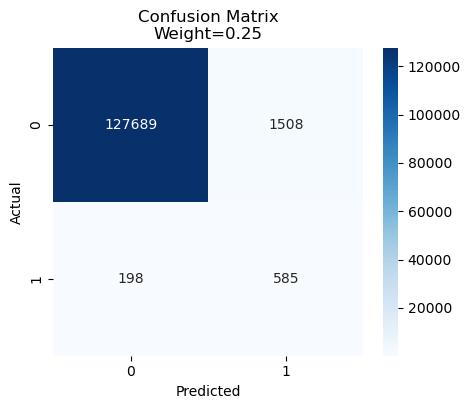


=== Classification Report ===
              precision    recall  f1-score   support

           0      0.998     0.988     0.993    129197
           1      0.280     0.747     0.407       783

    accuracy                          0.987    129980
   macro avg      0.639     0.868     0.700    129980
weighted avg      0.994     0.987     0.990    129980

Weight Multiplier : 0.5
Fraud Weight      : 87.74
Accuracy  : 0.972
Precision : 0.993
Recall    : 0.972
F1 Score  : 0.981
PR AUC    : 0.593
ROC AUC   : 0.973


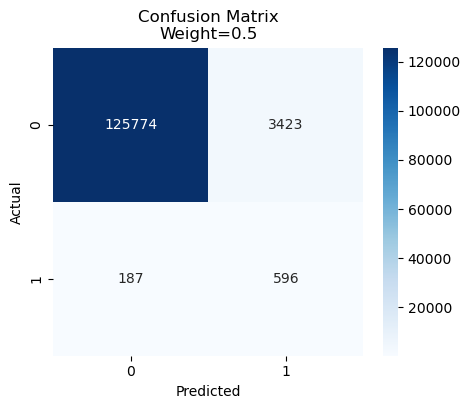


=== Classification Report ===
              precision    recall  f1-score   support

           0      0.999     0.974     0.986    129197
           1      0.148     0.761     0.248       783

    accuracy                          0.972    129980
   macro avg      0.573     0.867     0.617    129980
weighted avg      0.993     0.972     0.981    129980

Weight Multiplier : 1.0
Fraud Weight      : 175.48
Accuracy  : 0.945
Precision : 0.994
Recall    : 0.945
F1 Score  : 0.967
PR AUC    : 0.561
ROC AUC   : 0.975


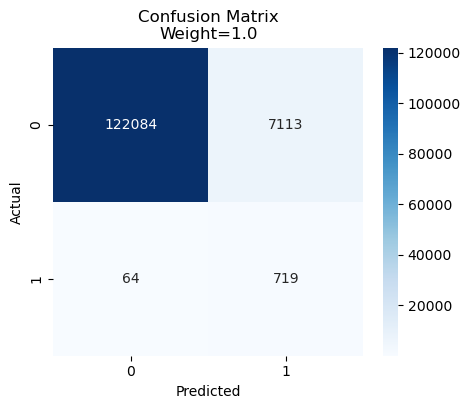


=== Classification Report ===
              precision    recall  f1-score   support

           0      0.999     0.945     0.971    129197
           1      0.092     0.918     0.167       783

    accuracy                          0.945    129980
   macro avg      0.546     0.932     0.569    129980
weighted avg      0.994     0.945     0.967    129980



In [19]:
# TRAIN LOOP
for multiplier in weight_list:

    fraud_weight = base_weight * multiplier

    train_weighted = train_df.withColumn(
        "classWeightCol",
        when(
            train_df.is_fraud == 1,
            fraud_weight
        ).otherwise(1.0)
    )

    rf = RandomForestClassifier(
        featuresCol="features",
        labelCol="is_fraud",
        weightCol="classWeightCol",
        numTrees=5,
        maxDepth=5,
        seed=42
    )

    rf_model = rf.fit(train_weighted)

    pred_rf = rf_model.transform(test_df)

    # metric evaluasi
    accuracy = accuracy_eval.evaluate(pred_rf)
    precision = precision_eval.evaluate(pred_rf)
    recall = recall_eval.evaluate(pred_rf)
    f1_score = f1_eval.evaluate(pred_rf)
    pr_auc = pr_eval.evaluate(pred_rf)
    roc_auc = roc_eval.evaluate(pred_rf)

    print("="*60)
    print(f"Weight Multiplier : {multiplier}")
    print(f"Fraud Weight      : {fraud_weight:.2f}")

    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1 Score  : {f1_score:.3f}")
    print(f"PR AUC    : {pr_auc:.3f}")
    print(f"ROC AUC   : {roc_auc:.3f}")

    pred_pd = pred_rf.select(
        "is_fraud",
        "prediction"
    ).toPandas()

     # SAVE RESULT
    results.append({
        "multiplier": multiplier,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc
    })

    # CONFUSION MATRIX
    cm = confusion_matrix(
        pred_pd["is_fraud"],
        pred_pd["prediction"]
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Confusion Matrix\nWeight={multiplier}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # CLASSIFICATION REPORT
    print("\n=== Classification Report ===")

    print(
        classification_report(
            pred_pd["is_fraud"],
            pred_pd["prediction"],
            digits=3
        )
    )


# Output

In [20]:
# RESULT TABLE
result_df = pd.DataFrame(results)
result_df


,multiplier,accuracy,precision,recall,f1_score,pr_auc,roc_auc
0,0.25,0.986875,0.994121,0.986875,0.989831,0.593625,0.974168
1,0.50,0.972226,0.993394,0.972226,0.981408,0.593253,0.972826
2,1.00,0.944784,0.994008,0.944784,0.966599,0.561223,0.975408


In [21]:
pred_rf.select("prediction","probability","is_fraud").write.mode("overwrite").parquet("hdfs://namenode:9000/data/analytics/fintech/fraud_prediction_weighted")